In [3]:
!pip install scikit-learn -i https://pypi.tuna.tsinghua.edu.cn/simple -q

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 90.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 59.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 25.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 33.9 MB/s eta 0:00:00


In [4]:
#整理Nir文章里的数据进行预测##############

Using device: cuda

模型权重加载验证
模型总参数数量: 27,068,806
成功加载权重文件: /home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup.pth
权重文件中包含的参数数量: 337

✅ 所有模型参数均成功加载！

📊 权重加载完成度: 100.00%

✅ 模型已成功加载并设置为评估模式
模型参数量: 27.07M

加载测试数据集
CSV文件列名: ['img_path', 'label']
测试集大小: 6 张图像

开始执行预测


预测进度: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]



整理预测结果
详细预测结果已保存至: /home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/paper_test预测结果_详细.csv
精简预测结果已保存至: /home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/paper_test预测结果_精简.csv

===== Paper-test 最终评估指标 =====
决定系数 R²:      0.4305
平均绝对误差 MAE: 2.4045
均方误差 MSE:     6.6016
均方根误差 RMSE:  2.5694
相对均方根误差 RMSPE: 15.95%
平均相对误差: 14.35%
最小绝对误差: 1.2178 (图像: 23.20-max-500nm-Joule2024-8(4)-1176-1190.jpg)
最大绝对误差: 4.0021 (图像: 17.30.jpg)

正在生成按误差从小到大排序的前20个图像可视化...
将显示误差最小的前6个图像
误差最小的前6个图像可视化已保存至: /home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/paper_test误差最小前20个图像标注.png

✅ 预测任务全部完成！

📁 生成的所有文件：
  - paper_test预测结果_详细.csv
  - paper_test预测结果_精简.csv
  - paper_test误差最小前20个图像标注.png


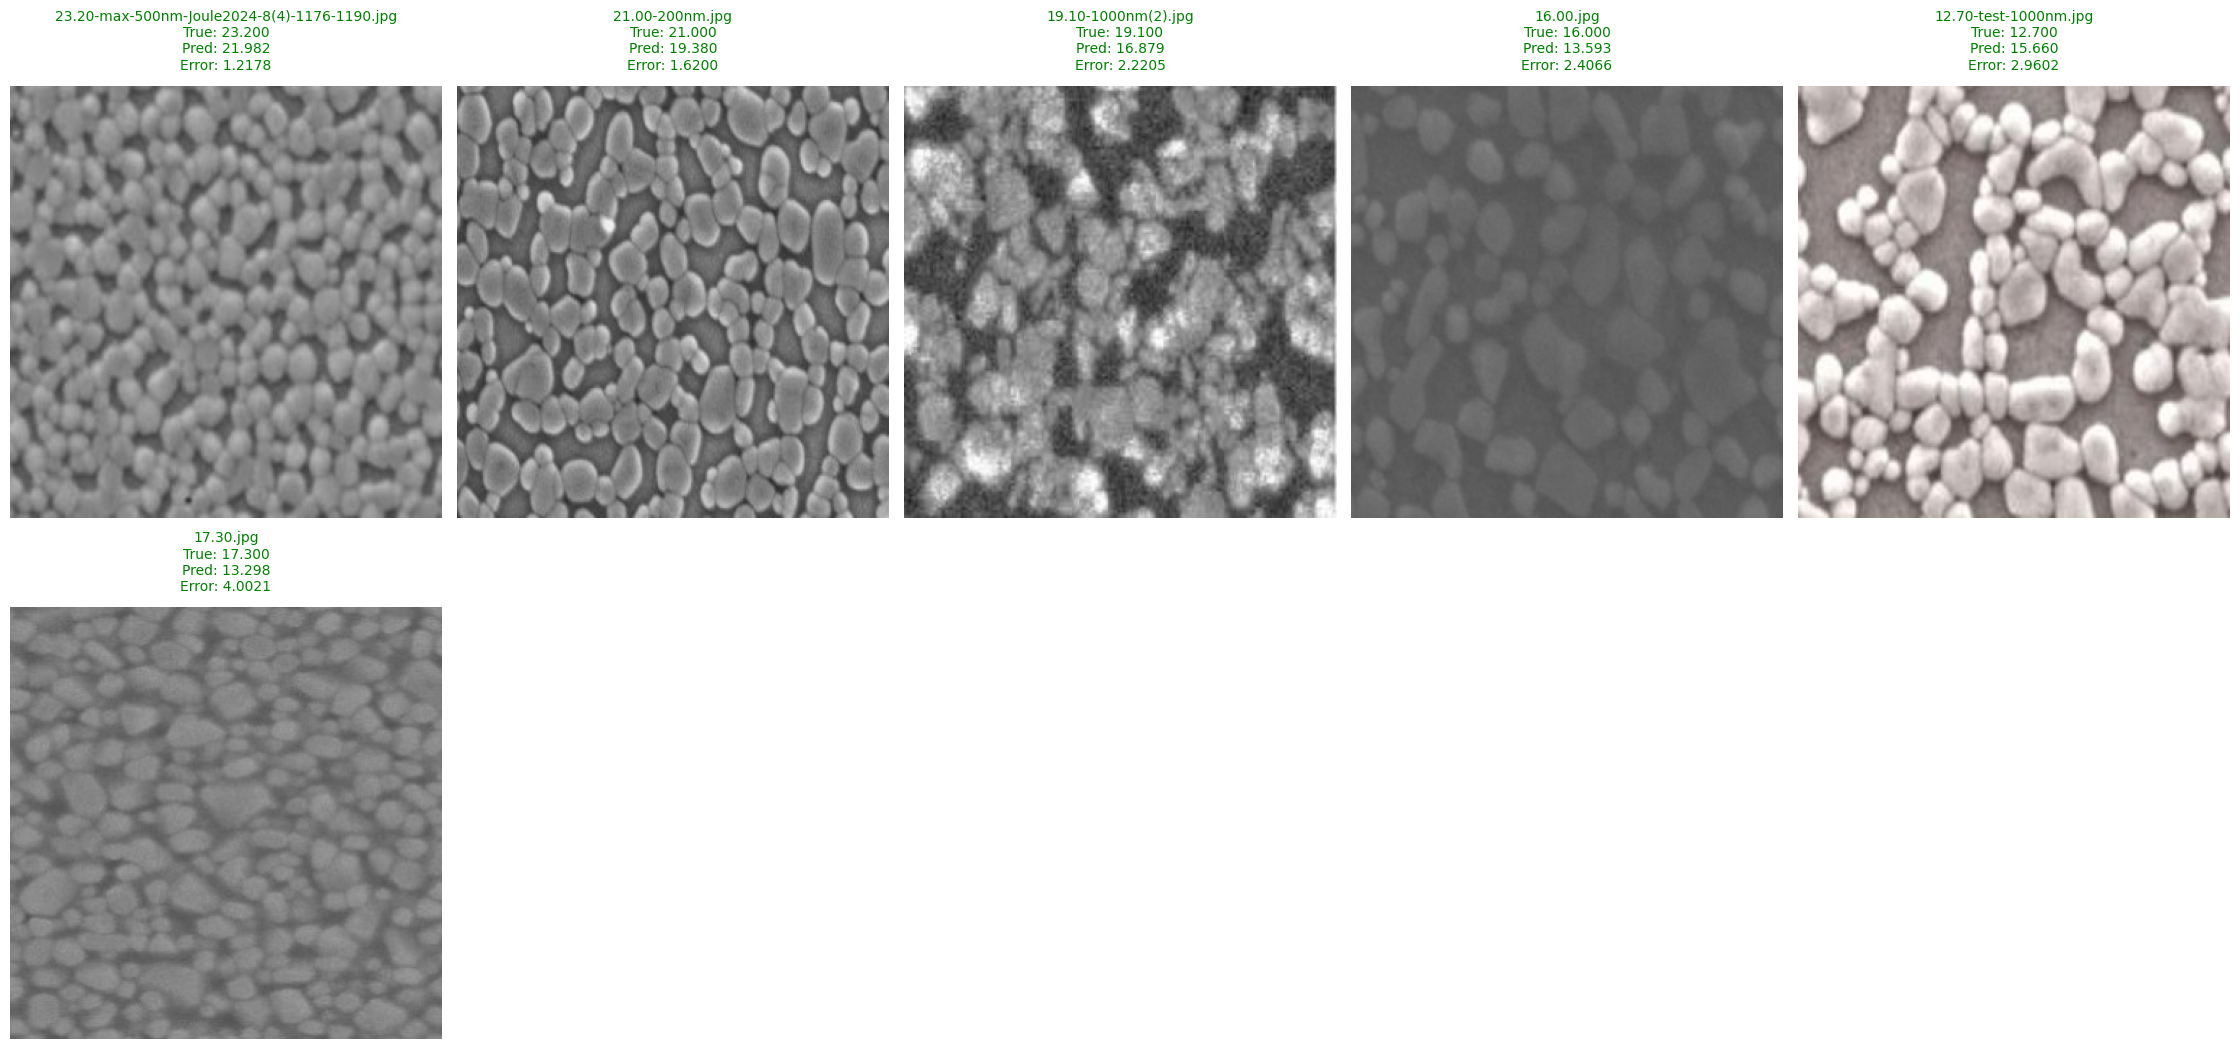

In [1]:
import os
import random
import warnings
import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
gc.collect()

# ==============================================
# 1. 基础配置（必须与训练时完全一致）
# ==============================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 超参数（必须与训练时一致）
img_size = 299
batch_size = 16
num_workers = 3
mean_values = [0.45564, 0.45563, 0.45561]
std_values = [0.13284, 0.13284, 0.13284]

# ==============================================
# 2. 路径设置（根据你的实际情况修改）
# ==============================================
# 训练好的模型权重路径
model_weights_path = '/home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup.pth'

# 测试集路径
paper_test_img_dir = Path('/home/featurize/work/111_IR/1-papar-test/test-paper')
paper_test_csv = Path('/home/featurize/work/111_IR/1-papar-test/test-paper.csv')

# 结果保存路径（与模型同目录）
save_dir = Path(model_weights_path).parent
save_dir.mkdir(parents=True, exist_ok=True)

# ==============================================
# 3. 数据预处理（与验证集完全一致）
# ==============================================
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_values, std=std_values)
])

# 用于可视化的原始图像变换（不进行归一化）
visual_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

# ==============================================
# 4. 增强版数据集类（增加原始图像获取）
# ==============================================
class SEMDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, visual_transform=None, target_transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.visual_transform = visual_transform
        self.target_transform = target_transform
        
        # 验证所有图像是否存在
        missing_files = []
        for idx in range(len(self.img_labels)):
            img_path = self.img_dir / self.img_labels.iloc[idx, 0]
            if not img_path.exists():
                missing_files.append(str(img_path))
        
        if missing_files:
            print(f"警告：以下 {len(missing_files)} 个图像文件不存在：")
            for f in missing_files[:5]:
                print(f"  - {f}")
            if len(missing_files) > 5:
                print(f"  ... 还有 {len(missing_files)-5} 个")

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_dir / self.img_labels.iloc[idx, 0]
        
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"加载图像失败: {img_path}, 错误: {e}")
            # 创建一个黑色图像作为替代
            image = Image.new('RGB', (img_size, img_size))
        
        label = float(self.img_labels.iloc[idx, 1])
        img_name = str(img_path.name)

        # 处理用于预测的图像
        pred_image = self.transform(image) if self.transform else image
        
        # 处理用于可视化的原始图像
        visual_image = self.visual_transform(image) if self.visual_transform else image

        if self.target_transform:
            label = self.target_transform(label)

        return pred_image, visual_image, torch.tensor(label, dtype=torch.float32), img_name

# ==============================================
# 5. 模型组件定义（与训练完全一致）
# ==============================================
class LIP(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(1) * 0.5)
        self.beta = nn.Parameter(torch.ones(1) * 0.5)

    def forward(self, x):
        var = torch.var(x, dim=(2, 3), keepdim=True)
        weight = F.softmax(var, dim=1)
        
        avg_pool = torch.mean(x, dim=(2, 3), keepdim=True)
        max_pool = torch.amax(x, dim=(2, 3), keepdim=True)
        
        lip_pool = self.alpha * (weight * avg_pool) + self.beta * ((1 - weight) * max_pool)
        return lip_pool

class ECA(nn.Module):
    def __init__(self, channel, gamma=2, b=1):
        super().__init__()
        t = int(abs((torch.log2(torch.tensor(channel, dtype=torch.float)) + b) / gamma))
        self.kernel_size = t if t % 2 == 1 else t + 1
        self.padding = self.kernel_size // 2
        
        self.conv = nn.Conv1d(1, 1, kernel_size=self.kernel_size, padding=self.padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        x = x.squeeze(-1).transpose(-1, -2)
        x = self.conv(x)
        x = x.transpose(-1, -2).unsqueeze(-1)
        channel_att = self.sigmoid(x)
        return channel_att

class CoordinateAttention(nn.Module):
    def __init__(self, channel, reduction=32):
        super().__init__()
        mid_channel = max(8, channel // reduction)
        
        self.conv1 = nn.Conv2d(1, mid_channel, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channel)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv_h = nn.Conv2d(mid_channel, channel, kernel_size=1, bias=False)
        self.conv_w = nn.Conv2d(mid_channel, channel, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        x_h = torch.mean(x, dim=3, keepdim=True)
        x_w = torch.mean(x, dim=2, keepdim=True)
        
        x_h_flat = x_h.view(b, c, h)
        x_w_flat = x_w.view(b, c, w)
        concat = torch.cat([x_h_flat, x_w_flat], dim=2).unsqueeze(1)
        
        concat = self.conv1(concat)
        concat = self.bn1(concat)
        concat = self.relu(concat)
        
        x_h, x_w = torch.split(concat, [h, w], dim=3)
        
        att_h = self.sigmoid(self.conv_h(x_h))
        att_h = att_h.mean(dim=2, keepdim=True)
        
        att_w = self.sigmoid(self.conv_w(x_w))
        att_w = att_w.mean(dim=2, keepdim=True)
        
        out = x * att_h * att_w
        return out

class CBAM_LIPCA(nn.Module):
    def __init__(self, channel, reduction=16, gamma=2, b=1):
        super().__init__()
        self.lip = LIP()
        self.eca = ECA(channel, gamma, b)
        self.coord_att = CoordinateAttention(channel, reduction)

    def forward(self, x):
        lip_out = self.lip(x)
        
        channel_att = self.eca(lip_out)
        x = x * channel_att
        
        refined_feat = self.coord_att(x)
        
        return refined_feat

class MultiScaleFusionWithCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cbam1 = CBAM_LIPCA(128)
        self.cbam2 = CBAM_LIPCA(256)
        self.cbam3 = CBAM_LIPCA(728)
        self.cbam4 = CBAM_LIPCA(2048)

        self.reduce_layer1 = nn.Conv2d(128, 256, kernel_size=1, bias=False)
        self.reduce_layer2 = nn.Conv2d(256, 256, kernel_size=1, bias=False)
        self.reduce_layer3 = nn.Conv2d(728, 256, kernel_size=1, bias=False)
        self.reduce_layer4 = nn.Conv2d(2048, 256, kernel_size=1, bias=False)

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, feat1, feat2, feat3, feat4):
        feat1 = self.cbam1(feat1)
        feat2 = self.cbam2(feat2)
        feat3 = self.cbam3(feat3)
        feat4 = self.cbam4(feat4)

        feat1 = self.reduce_layer1(feat1)
        feat2 = self.reduce_layer2(feat2)
        feat3 = self.reduce_layer3(feat3)
        feat4 = self.reduce_layer4(feat4)

        feat1 = F.interpolate(feat1, size=(10,10), mode='bilinear', align_corners=False)
        feat2 = F.interpolate(feat2, size=(10,10), mode='bilinear', align_corners=False)
        feat3 = F.interpolate(feat3, size=(10,10), mode='bilinear', align_corners=False)

        fused_feat = torch.cat([feat1, feat2, feat3, feat4], dim=1)
        fused_feat = self.fusion_conv(fused_feat)
        return fused_feat

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False):
        super(SeparableConv2d, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, dilation, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class Block(nn.Module):
    def __init__(self, in_filters, out_filters, reps, strides=1, start_with_relu=True, grow_first=True):
        super(Block, self).__init__()

        if out_filters != in_filters or strides != 1:
            self.skip = nn.Conv2d(in_filters, out_filters, 1, stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip = None

        self.relu = nn.ReLU(inplace=True)
        rep = []

        filters = in_filters
        if grow_first:
            rep.append(self.relu)
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(out_filters))
            filters = out_filters

        for i in range(reps - 1):
            rep.append(self.relu)
            rep.append(SeparableConv2d(filters, filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(filters))

        if not grow_first:
            rep.append(self.relu)
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(out_filters))

        if not start_with_relu:
            rep = rep[1:]
        else:
            rep[0] = nn.ReLU(inplace=False)

        if strides != 1:
            rep.append(nn.MaxPool2d(3, strides, 1))
        self.rep = nn.Sequential(*rep)

    def forward(self, inp):
        x = self.rep(inp)

        if self.skip is not None:
            skip = self.skip(inp)
            skip = self.skipbn(skip)
        else:
            skip = inp

        x += skip
        return x

class Xception(nn.Module):
    def __init__(self, num_classes=1000):
        super(Xception, self).__init__()
        
        self.num_classes = num_classes

        self.conv1 = nn.Conv2d(3, 32, 3, 2, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(32, 64, 3, bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        self.block1 = Block(64, 128, 2, 2, start_with_relu=False, grow_first=True)
        self.block2 = Block(128, 256, 2, 2, start_with_relu=True, grow_first=True)
        self.block3 = Block(256, 728, 2, 2, start_with_relu=True, grow_first=True)

        self.block4 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block5 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block6 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block7 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block8 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block9 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block10 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block11 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)

        self.block12 = Block(728, 1024, 2, 2, start_with_relu=True, grow_first=False)

        self.conv3 = SeparableConv2d(1024, 1536, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(1536)

        self.conv4 = SeparableConv2d(1536, 2048, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(2048)

        self.fc = nn.Linear(2048, num_classes)

class SEM_Model_MicroNet_MultiScale_CBAM(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.conv2,
            backbone.bn2,
            backbone.relu
        )

        self.block1 = backbone.block1
        self.block2 = backbone.block2
        self.block3 = nn.Sequential(
            backbone.block3, backbone.block4, backbone.block5,
            backbone.block6, backbone.block7, backbone.block8,
            backbone.block9, backbone.block10, backbone.block11
        )
        self.block4 = nn.Sequential(
            backbone.block12, backbone.conv3, backbone.bn3, backbone.relu,
            backbone.conv4, backbone.bn4, backbone.relu
        )

        self.ms_fusion_cbam = MultiScaleFusionWithCBAM()

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(512),  
            nn.Dropout(0.05),      
            nn.Linear(512, 256),  
            nn.ReLU(),           
            nn.Linear(256, 1)     
        )

    def forward(self, x):
        x = self.stem(x)
        feat1 = self.block1(x)
        feat2 = self.block2(feat1)
        feat3 = self.block3(feat2)
        feat4 = self.block4(feat3)

        fused_feat = self.ms_fusion_cbam(feat1, feat2, feat3, feat4)
        
        out = self.head(fused_feat).squeeze(-1)
        return out

# ==============================================
# 6. 指标计算函数
# ==============================================
def calc_metrics(preds, targets):
    preds = preds.cpu().numpy() if isinstance(preds, torch.Tensor) else preds
    targets = targets.cpu().numpy() if isinstance(targets, torch.Tensor) else targets
    r2 = r2_score(targets, preds)
    mae = mean_absolute_error(targets, preds)
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse

def calc_rmspe(preds, targets):
    preds = np.asarray(preds)
    targets = np.asarray(targets)
    targets_safe = targets + 1e-8
    percentage_errors = (preds - targets_safe) / targets_safe
    rmspe = np.sqrt(np.mean(np.square(percentage_errors))) * 100  
    return rmspe

# ==============================================
# 7. 加载训练好的模型（增强权重验证）
# ==============================================
print("\n" + "="*80)
print("模型权重加载验证")
print("="*80)

# 初始化模型结构
base_model = Xception(num_classes=1000)
model = SEM_Model_MicroNet_MultiScale_CBAM(base_model).to(device)

# 计算模型总参数数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型总参数数量: {total_params:,}")

# 加载权重
try:
    checkpoint = torch.load(model_weights_path, map_location=device)
    print(f"成功加载权重文件: {model_weights_path}")
    print(f"权重文件中包含的参数数量: {len(checkpoint):,}")
    
    # 加载权重并获取缺失和意外的参数
    missing, unexpected = model.load_state_dict(checkpoint, strict=False)
    
    if missing:
        print(f"\n⚠️ 警告：缺失 {len(missing)} 个权重参数")
        if len(missing) < 15:
            for key in missing:
                print(f"   - {key}")
        else:
            print(f"   缺失参数过多，仅显示前15个")
            for key in missing[:15]:
                print(f"   - {key}")
    else:
        print("\n✅ 所有模型参数均成功加载！")
    
    if unexpected:
        print(f"\n⚠️ 警告：发现 {len(unexpected)} 个未预期的权重参数")
        if len(unexpected) < 15:
            for key in unexpected:
                print(f"   - {key}")
        else:
            print(f"   未预期参数过多，仅显示前15个")
            for key in unexpected[:15]:
                print(f"   - {key}")
    
    # 计算成功加载的参数比例
    loaded_params = total_params - sum(p.numel() for p in model.parameters() if p.data.abs().sum() < 1e-10)
    load_ratio = loaded_params / total_params * 100
    print(f"\n📊 权重加载完成度: {load_ratio:.2f}%")
    
except Exception as e:
    print(f"\n❌ 加载模型失败: {e}")
    exit(1)

model.eval()  # 必须设置为评估模式
print(f"\n✅ 模型已成功加载并设置为评估模式")
print(f"模型参数量: {total_params/1e6:.2f}M")

# ==============================================
# 8. 加载测试数据集
# ==============================================
print("\n" + "="*80)
print("加载测试数据集")
print("="*80)

# 检查路径
if not paper_test_img_dir.exists():
    raise FileNotFoundError(f"图像文件夹不存在: {paper_test_img_dir}")
if not paper_test_csv.exists():
    raise FileNotFoundError(f"标签文件不存在: {paper_test_csv}")

# 加载标签
try:
    paper_test_df = pd.read_csv(paper_test_csv)
    print(f"CSV文件列名: {list(paper_test_df.columns)}")
    
    # 检查CSV文件是否有至少两列
    if paper_test_df.shape[1] < 2:
        raise ValueError("CSV文件必须至少包含两列：文件名和标签")
    
    print(f"测试集大小: {len(paper_test_df)} 张图像")
    
except Exception as e:
    print(f"加载CSV文件失败: {e}")
    exit(1)

# 创建数据集和数据加载器（同时返回用于预测和可视化的图像）
paper_test_dataset = SEMDataset(
    paper_test_df, 
    paper_test_img_dir, 
    transform=test_transform,
    visual_transform=visual_transform
)

paper_test_loader = DataLoader(
    paper_test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

# ==============================================
# 9. 执行预测
# ==============================================
print("\n" + "="*80)
print("开始执行预测")
print("="*80)

paper_preds, paper_targs, paper_fnames, paper_visual_imgs = [], [], [], []

with torch.no_grad():  # 禁用梯度计算，加速预测并节省内存
    for pred_imgs, visual_imgs, labels, filenames in tqdm(paper_test_loader, desc="预测进度"):
        pred_imgs = pred_imgs.to(device, non_blocking=True)
        outputs = model(pred_imgs)
        
        paper_preds.extend(outputs.cpu().numpy())
        paper_targs.extend(labels.numpy())
        paper_fnames.extend(filenames)
        paper_visual_imgs.extend(visual_imgs)

# ==============================================
# 10. 整理并保存结果
# ==============================================
print("\n" + "="*80)
print("整理预测结果")
print("="*80)

# 创建结果DataFrame
df_paper_test = pd.DataFrame({
    "图像文件名": paper_fnames,
    "真实EQE值": paper_targs,
    "预测EQE值": paper_preds,
    "绝对误差": np.abs(np.array(paper_preds) - np.array(paper_targs)),
    "相对误差(%)": np.abs(np.array(paper_preds) - np.array(paper_targs)) / (np.array(paper_targs) + 1e-8) * 100
})

# 🔴 修改：按绝对误差从小到大排序（误差小的排在前面）
df_paper_test = df_paper_test.sort_values(by="绝对误差", ascending=True).reset_index(drop=True)

# 保存结果到CSV
result_csv_path = save_dir / "paper_test预测结果_详细.csv"
df_paper_test.to_csv(result_csv_path, index=False, encoding="utf-8-sig")
print(f"详细预测结果已保存至: {result_csv_path}")

# 保存精简版结果（只包含文件名和预测值）
simple_result_path = save_dir / "paper_test预测结果_精简.csv"
df_simple = df_paper_test[["图像文件名", "预测EQE值"]]
df_simple.to_csv(simple_result_path, index=False, encoding="utf-8-sig")
print(f"精简预测结果已保存至: {simple_result_path}")

# ==============================================
# 11. 计算并打印评估指标
# ==============================================
r2_paper, mae_paper, mse_paper, rmse_paper = calc_metrics(paper_preds, paper_targs)
rmspe_paper = calc_rmspe(paper_preds, paper_targs)

print("\n" + "="*80)
print("===== Paper-test 最终评估指标 =====")
print(f"决定系数 R²:      {r2_paper:.4f}")
print(f"平均绝对误差 MAE: {mae_paper:.4f}")
print(f"均方误差 MSE:     {mse_paper:.4f}")
print(f"均方根误差 RMSE:  {rmse_paper:.4f}")
print(f"相对均方根误差 RMSPE: {rmspe_paper:.2f}%")
print(f"平均相对误差: {df_paper_test['相对误差(%)'].mean():.2f}%")
print(f"最小绝对误差: {df_paper_test['绝对误差'].min():.4f} (图像: {df_paper_test.iloc[0]['图像文件名']})")
print(f"最大绝对误差: {df_paper_test['绝对误差'].max():.4f} (图像: {df_paper_test.iloc[-1]['图像文件名']})")
print("="*80)

# ==============================================
# 12. 生成按误差从小到大排序的前20个图像可视化
# ==============================================
print("\n正在生成按误差从小到大排序的前20个图像可视化...")

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 🔴 修改：只显示前20个误差最小的图像
top_n_best = min(20, len(paper_visual_imgs))
print(f"将显示误差最小的前{top_n_best}个图像")

# 计算网格大小
n_cols = 5  # 每行5个图像
n_rows = (top_n_best + n_cols - 1) // n_cols

# 调整图形大小以适应标题
plt.figure(figsize=(n_cols * 4.5, n_rows * 5.5))

for i in range(top_n_best):
    # 获取按误差从小到大排序后的第i个图像信息
    img_name = df_paper_test.iloc[i]['图像文件名']
    true_val = df_paper_test.iloc[i]['真实EQE值']
    pred_val = df_paper_test.iloc[i]['预测EQE值']
    error = df_paper_test.iloc[i]['绝对误差']
    
    # 找到对应的可视化图像
    img_idx = paper_fnames.index(img_name)
    img = paper_visual_imgs[img_idx].permute(1, 2, 0).numpy()  # CHW -> HWC
    
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(img)
    plt.title(f"{img_name}\nTrue: {true_val:.3f}\nPred: {pred_val:.3f}\nError: {error:.4f}", 
              fontsize=10, pad=12, color='green')  # 使用绿色表示预测效果好
    plt.axis('off')

plt.tight_layout()

# 保存图像
best_images_path = save_dir / "paper_test误差最小前20个图像标注.png"
plt.savefig(best_images_path, dpi=200, bbox_inches='tight')
print(f"误差最小的前{top_n_best}个图像可视化已保存至: {best_images_path}")

print("\n" + "="*80)
print("✅ 预测任务全部完成！")
print("="*80)

# 显示生成的文件列表
print("\n📁 生成的所有文件：")
print(f"  - {result_csv_path.name}")
print(f"  - {simple_result_path.name}")
print(f"  - {best_images_path.name}")